In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('50_Startups.csv')

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
pd.unique(df['State'])

array(['New York', 'California', 'Florida'], dtype=object)

In [6]:
dummy=pd.get_dummies(df['State'],drop_first=True)

In [7]:
df=pd.concat([df,dummy],axis=1)

In [8]:
df=df.drop(df[['State']],axis=1)

In [9]:
X = df[['R&D Spend','Administration','Marketing Spend','Florida','New York']].values

In [10]:
y = df['Profit'].values.reshape(-1,1)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model = LinearRegression()

In [13]:
model.fit(X, y)

LinearRegression()

In [14]:
model.coef_

array([[ 8.06023114e-01, -2.70043196e-02,  2.69798610e-02,
         1.98788793e+02, -4.18870191e+01]])

In [15]:
model.intercept_

array([50125.3438316])

In [16]:
model.predict(np.array([5,5,5,5,5]).reshape(1,-1))

array([[50913.88269353]])

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [19]:
lr = LinearRegression()

In [20]:
lr.fit(X_train, y_train)

LinearRegression()

In [21]:
y_train_pred = lr.predict(X_train)

In [22]:
y_test_pred = lr.predict(X_test)

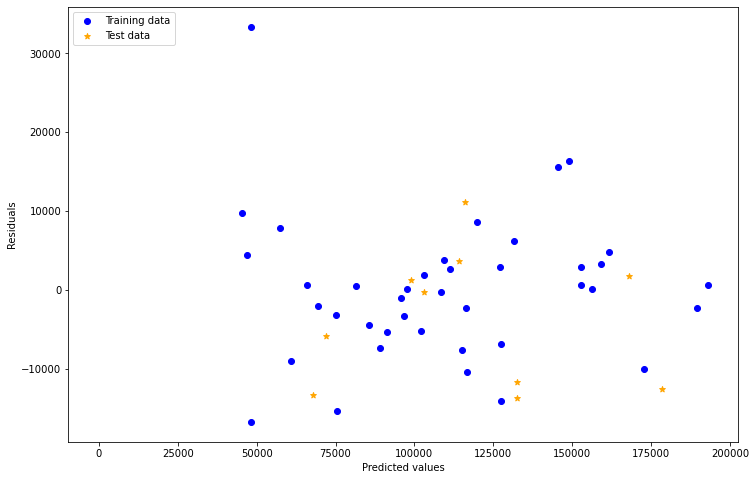

In [23]:
plt.figure(figsize=(12,8))
plt.scatter(y_train_pred, y_train_pred - y_train, c='blue', marker='o', label='Training data')
plt.scatter(y_test_pred, y_test_pred - y_test, c='orange', marker='*', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-10, xmax=50, lw=2, color='k')
plt.show()

In [24]:
model.predict(np.array([5,5,5,5,5]).reshape(1,-1))

array([[50913.88269353]])

In [25]:
from sklearn.metrics import mean_squared_error

In [26]:
mean_squared_error(y_train, y_train_pred)

81571001.80077371

In [27]:
mean_squared_error(y_test, y_test_pred)

83502864.03257738

In [28]:
from sklearn.metrics import r2_score

In [29]:
r2_score(y_train, y_train_pred)

0.9501847627493607

In [30]:
r2_score(y_test, y_test_pred)

0.9347068473282425

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred

array([[101818.58738693],
       [135528.60078159],
       [135664.64259063],
       [ 74956.31104907],
       [182276.18673283],
       [114279.80403012],
       [ 69606.52160902],
       [ 97617.29632021],
       [114833.30513844],
       [172277.13381666]])

In [33]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
lm = LinearRegression()
scores = cross_val_score(lm,X_train,y_train,scoring='r2',cv=5)
scores

array([0.64120447, 0.88536669, 0.90980771, 0.8961349 , 0.97415038])

In [34]:
accuracy_fold=np.mean(abs(scores))
accuracy_fold

0.8613328292604333

In [35]:
scores = cross_val_score(lm, X_train,y_train, scoring="neg_mean_squared_error",cv=5)
print('Score = ',scores)
accuracry_fold=np.mean(abs(scores))
print('MSE = ',accuracy_fold)

Score =  [-2.41561139e+08 -9.85464665e+07 -1.84071510e+08 -1.14662125e+08
 -8.03878333e+07]
MSE =  0.8613328292604333


In [36]:
#Kfold with 5 splits

folds = KFold(n_splits = 5, shuffle = True, random_state = 42)
scores = cross_val_score(lm, X_train, y_train, scoring='r2',cv=folds)
scores

array([0.97781314, 0.90584967, 0.98710158, 0.87646305, 0.94142153])

# Stratified Fold

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

In [44]:
hyper_params = [{'n_features_to_select': list(range(1, 14))}]

In [45]:
lm = LinearRegression()
lr=lm.fit(X_train,y_train)
rfe = RFE(lm)

In [46]:
from sklearn.model_selection import GridSearchCV
model_cv = GridSearchCV(estimator=rfe,
                        param_grid = hyper_params,
                        scoring='r2',
                        cv=folds)

model_cv.fit(X_train,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RFE(estimator=LinearRegression()),
             param_grid=[{'n_features_to_select': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13]}],
             scoring='r2')